# COMP8410 Assignment 2 — TripoSR Open-Source Counterpart Experiment

**Case study:** Roblox GenerationService / Cube 3D  
**Open-source counterpart:** TripoSR  
**Goal:** produce genuine evidence for the 7-mark Hands-On Exploration criterion.

This notebook:
- uses the official `VAST-AI-Research/TripoSR` repository;
- creates an isolated **Python 3.11** environment so modern Colab's Python 3.13 does not break older TripoSR dependencies;
- avoids the old `torchmcubes` build problem by replacing only the Marching Cubes helper with `scikit-image`;
- runs TripoSR on **2–3 uploaded object images**;
- saves processed inputs and OBJ meshes;
- records inference time, peak GPU memory, vertices, faces, watertightness, connected components, extents and surface area;
- creates interactive 3D visualisations for screenshots;
- downloads a ZIP containing the evidence.

## Recommended test set
Upload **three single-object images**:
1. a simple object — chair, shoe, teapot, toy;
2. a thin-structure object — lamp, bicycle-like object, stool;
3. a difficult/asymmetric object — car, open-door vehicle, detailed prop.

Use your own or appropriately licensed images and keep the source details for your report.

In [1]:
# CELL 1 — GPU/runtime evidence (screenshot this)
import subprocess, sys, os, platform

subprocess.run(["nvidia-smi"], check=False)

print("\nSystem Python:", sys.version)
print("Platform:", platform.platform())


System Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


In [2]:
# CELL 2 — Clone the official TripoSR repository
import os, shutil, subprocess

REPO = "/content/TripoSR"

if os.path.exists(REPO):
    shutil.rmtree(REPO)

subprocess.run(
    ["git", "clone", "-q", "https://github.com/VAST-AI-Research/TripoSR.git", REPO],
    check=True,
)

print("Cloned official repository:", REPO)
print("tsr/system.py exists:", os.path.exists(f"{REPO}/tsr/system.py"))
print("tsr/utils.py exists:", os.path.exists(f"{REPO}/tsr/utils.py"))

Cloned official repository: /content/TripoSR
tsr/system.py exists: True
tsr/utils.py exists: True


In [3]:
# CELL 3 — Create an isolated Python 3.11 environment.
# This avoids current Colab Python 3.13 incompatibilities with older TripoSR dependencies.

import subprocess, sys, os

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)

# Install Python 3.11 through uv if needed.
subprocess.run(["uv", "python", "install", "3.11"], check=True)

VENV = "/content/triposr-venv"
if os.path.exists(VENV):
    import shutil
    shutil.rmtree(VENV)

subprocess.run(["uv", "venv", VENV, "--python", "3.11"], check=True)

PY = f"{VENV}/bin/python"
PIP = f"{VENV}/bin/pip"

print("Virtual environment:", VENV)
subprocess.run([PY, "--version"], check=True)

Virtual environment: /content/triposr-venv


CompletedProcess(args=['/content/triposr-venv/bin/python', '--version'], returncode=0)

In [9]:
# CELL 4 — Install a stable TripoSR inference stack inside Python 3.11.
# We do NOT install torchmcubes; the next cell replaces only that helper.

import subprocess, os

PY = "/content/triposr-venv/bin/python"

# Ensure pip is installed and upgraded in the venv
subprocess.run([PY, "-m", "ensurepip"], check=True)
subprocess.run([PY, "-m", "pip", "install", "--upgrade", "pip"], check=True)

# CUDA-enabled PyTorch for the T4.
try:
    result = subprocess.run(
        [
            PY, "-m", "pip", "install",
            "--index-url", "https://download.pytorch.org/whl/cu121",
            "torch==2.3.0", "torchvision==0.18.0"
        ],
        check=True,
        capture_output=True, # Capture output
        text=True # Decode stdout/stderr as text
    )
    print(result.stdout)
    print(result.stderr)
except subprocess.CalledProcessError as e:
    print("Error installing PyTorch and torchvision:")
    print("STDOUT:", e.stdout)
    print("STDERR:", e.stderr)
    raise # Re-raise the exception after printing details

# Core model and analysis packages.
subprocess.run([
    PY, "-m", "pip", "install", "-q",
    "numpy==1.26.4",
    "scipy==1.11.4",
    "scikit-image==0.22.0",
    "Pillow==10.1.0",
    "omegaconf==2.3.0",
    "einops==0.7.0",
    "transformers==4.45.0",
    "trimesh==4.0.5",
    "rembg==2.0.50",
    "onnxruntime==1.17.3",
    "huggingface-hub==0.34.0",
    "imageio[ffmpeg]",
], check=True)

print("Dependencies installed successfully.")

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.0/781.0 MB 30.9 MB/s  0:00:14
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 27.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 74.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 178.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 70.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 21.3 MB/s  0:00:35
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 64.8 MB/s  0:00:06
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 63.9 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 65.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 63.3 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 58.2 MB/s  0:00:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 74.2 MB/s

In [10]:
# CELL 5 — Replace ONLY TripoSR's old torchmcubes helper with scikit-image Marching Cubes.
# The TripoSR neural model and pretrained weights remain unchanged.

from pathlib import Path

target = Path("/content/TripoSR/tsr/models/isosurface.py")

patched = r"""
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
from skimage import measure


class IsosurfaceHelper(nn.Module):
    points_range: Tuple[float, float] = (0, 1)

    @property
    def grid_vertices(self) -> torch.FloatTensor:
        raise NotImplementedError


class MarchingCubeHelper(IsosurfaceHelper):
    def __init__(self, resolution: int) -> None:
        super().__init__()
        self.resolution = resolution
        self._grid_vertices: Optional[torch.FloatTensor] = None

    @property
    def grid_vertices(self) -> torch.FloatTensor:
        if self._grid_vertices is None:
            x, y, z = (
                torch.linspace(*self.points_range, self.resolution),
                torch.linspace(*self.points_range, self.resolution),
                torch.linspace(*self.points_range, self.resolution),
            )
            x, y, z = torch.meshgrid(x, y, z, indexing="ij")
            self._grid_vertices = torch.cat(
                [x.reshape(-1, 1), y.reshape(-1, 1), z.reshape(-1, 1)],
                dim=-1,
            )
        return self._grid_vertices

    def forward(self, level: torch.FloatTensor):
        level = -level.view(
            self.resolution,
            self.resolution,
            self.resolution
        )

        volume = level.detach().float().cpu().numpy()

        verts, faces, _, _ = measure.marching_cubes(
            volume,
            level=0.0
        )

        v_pos = torch.from_numpy(verts.astype(np.float32))
        t_pos_idx = torch.from_numpy(faces.astype(np.int64))

        # Match TripoSR's original axis convention.
        v_pos = v_pos[..., [2, 1, 0]]
        v_pos = v_pos / (self.resolution - 1.0)

        return v_pos.to(level.device), t_pos_idx.to(level.device)
"""

target.write_text(patched, encoding="utf-8")
print("Patched:", target)

Patched: /content/TripoSR/tsr/models/isosurface.py


In [13]:
# CELL 6 — Verify the isolated environment and TripoSR import path.

import subprocess, textwrap, os

verify_script = r'''
import os, sys
REPO = "/content/TripoSR"
sys.path.insert(0, REPO)

import torch
import numpy as np
import trimesh
import rembg
import transformers
import huggingface_hub
import tsr

print("Python:", sys.version.split()[0])
print("tsr imported from:", tsr.__path__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 2))
print("NumPy:", np.__version__)
print("Transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("rembg import: OK")

assert any(os.path.abspath(p).startswith(REPO) for p in tsr.__path__), "Wrong tsr package imported"
assert torch.cuda.is_available(), "Enable a T4 GPU in Runtime settings"
'''

path = "/content/verify_triposr.py"
open(path, "w").write(verify_script)

try:
    result = subprocess.run(
        ["/content/triposr-venv/bin/python", path],
        check=True,
        capture_output=True,
        text=True
    )
    print(result.stdout)
    print(result.stderr)
except subprocess.CalledProcessError as e:
    print("Error running verification script:")
    print("STDOUT:", e.stdout)
    print("STDERR:", e.stderr)
    raise # Re-raise the exception after printing details

Python: 3.11.16
tsr imported from: _NamespacePath(['/content/TripoSR/tsr'])
PyTorch: 2.3.0+cu121
CUDA available: True
GPU: Tesla T4
VRAM GB: 14.56
NumPy: 1.26.4
Transformers: 4.45.0
huggingface_hub: 0.34.0
rembg import: OK




## Upload 2–3 input images

For the best rubric evidence, use **three objects of different difficulty**.

The experiment will:
- remove the background;
- center the foreground;
- run one TripoSR reconstruction per image;
- export an OBJ mesh;
- measure geometry and runtime.

**Do not use screenshots containing several objects.** One object per image gives cleaner evidence.

In [15]:
# CELL 7 — Upload your 2–3 input images

from google.colab import files
from pathlib import Path
import shutil, os

INPUT_DIR = Path("/content/triposr_inputs")
if INPUT_DIR.exists():
    shutil.rmtree(INPUT_DIR)
INPUT_DIR.mkdir(parents=True)

uploaded = files.upload()

if len(uploaded) < 2:
    raise RuntimeError("Upload at least 2 object images; 3 is better for the report.")

for name, data in uploaded.items():
    path = INPUT_DIR / name
    path.write_bytes(data)
    print("Saved:", path)

print("\nNumber of test images:", len(uploaded))

Saving images (5).jpg to images (5).jpg
Saving images (4).jpg to images (4).jpg
Saving images (3).jpg to images (3).jpg
Saved: /content/triposr_inputs/images (5).jpg
Saved: /content/triposr_inputs/images (4).jpg
Saved: /content/triposr_inputs/images (3).jpg

Number of test images: 3


In [16]:
# CELL 8 — Create the experiment runner inside the isolated Python 3.11 environment.

runner = r"""
import os, sys, time, json, csv, glob
from pathlib import Path

REPO = "/content/TripoSR"
sys.path.insert(0, REPO)

import numpy as np
import torch
import trimesh
import rembg
from PIL import Image

from tsr.system import TSR
from tsr.utils import remove_background, resize_foreground

DEVICE = "cuda:0"
INPUT_DIR = Path("/content/triposr_inputs")
OUTPUT_ROOT = Path("/content/triposr_outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MC_RESOLUTION = 192
CHUNK_SIZE = 8192

print("Loading TripoSR...")
model = TSR.from_pretrained(
    "stabilityai/TripoSR",
    config_name="config.yaml",
    weight_name="model.ckpt",
)
model.renderer.set_chunk_size(CHUNK_SIZE)
model.to(DEVICE)
model.eval()
print("Model loaded.")

print("Preparing background-removal model...")
rembg_session = rembg.new_session()
print("Background-removal model ready.")

image_paths = []
for ext in ("*.png", "*.jpg", "*.jpeg", "*.webp"):
    image_paths.extend(INPUT_DIR.glob(ext))
image_paths = sorted(image_paths)

if len(image_paths) < 2:
    raise RuntimeError("Need at least two input images.")

records = []

for idx, image_path in enumerate(image_paths, start=1):
    print("\\n" + "=" * 80)
    print(f"EXPERIMENT {idx}: {image_path.name}")

    out_dir = OUTPUT_ROOT / f"experiment_{idx}"
    out_dir.mkdir(parents=True, exist_ok=True)

    raw = Image.open(image_path).convert("RGB")
    original_w, original_h = raw.size

    # Official TripoSR-style preprocessing.
    rgba = remove_background(raw, rembg_session)
    rgba = resize_foreground(rgba, 0.85)

    rgba_np = np.asarray(rgba).astype(np.float32) / 255.0
    rgb_np = (
        rgba_np[:, :, :3] * rgba_np[:, :, 3:4]
        + (1.0 - rgba_np[:, :, 3:4]) * 0.5
    )
    processed = Image.fromarray((rgb_np * 255).astype(np.uint8))
    processed_path = out_dir / "processed_input.png"
    processed.save(processed_path)

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        scene_codes = model([processed], device=DEVICE)
        mesh = model.extract_mesh(
            scene_codes,
            has_vertex_color=True,
            resolution=MC_RESOLUTION,
        )[0]

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    mesh_path = out_dir / "mesh.obj"
    mesh.export(mesh_path)

    components = mesh.split(only_watertight=False)
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3

    row = {
        "experiment": idx,
        "input_file": image_path.name,
        "input_width": original_w,
        "input_height": original_h,
        "mc_resolution": MC_RESOLUTION,
        "inference_and_mesh_seconds": round(elapsed, 3),
        "peak_allocated_vram_GB": round(peak_vram, 3),
        "vertices": int(len(mesh.vertices)),
        "faces": int(len(mesh.faces)),
        "watertight": bool(mesh.is_watertight),
        "connected_components": int(len(components)),
        "extent_x": round(float(mesh.extents[0]), 5),
        "extent_y": round(float(mesh.extents[1]), 5),
        "extent_z": round(float(mesh.extents[2]), 5),
        "surface_area": round(float(mesh.area), 5),
        "processed_input": str(processed_path),
        "mesh_path": str(mesh_path),
    }
    records.append(row)

    print("Input:", image_path.name)
    print("Inference + mesh extraction:", f"{elapsed:.3f} s")
    print("Peak allocated GPU memory:", f"{peak_vram:.3f} GB")
    print("Vertices:", row["vertices"])
    print("Faces:", row["faces"])
    print("Watertight:", row["watertight"])
    print("Connected components:", row["connected_components"])
    print("Extents:", mesh.extents)
    print("Surface area:", row["surface_area"])
    print("Saved mesh:", mesh_path)

json_path = OUTPUT_ROOT / "triposr_results.json"
csv_path = OUTPUT_ROOT / "triposr_results.csv"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2)

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=records[0].keys())
    writer.writeheader()
    writer.writerows(records)

print("\\nSUCCESS: all TripoSR experiments completed.")
print("JSON:", json_path)
print("CSV:", csv_path)
"""

runner_path = "/content/run_triposr_experiment.py"
open(runner_path, "w").write(runner)
print("Created:", runner_path)

Created: /content/run_triposr_experiment.py


In [17]:
# CELL 9 — RUN THE ACTUAL EXPERIMENT
# Screenshot the final printed metrics.

import subprocess

result = subprocess.run(
    ["/content/triposr-venv/bin/python", "/content/run_triposr_experiment.py"],
    text=True,
)

if result.returncode != 0:
    raise RuntimeError(
        "TripoSR experiment failed. Copy the RED error output to ChatGPT."
    )

print("\nTripoSR experiment finished successfully.")


TripoSR experiment finished successfully.



 experiment_1


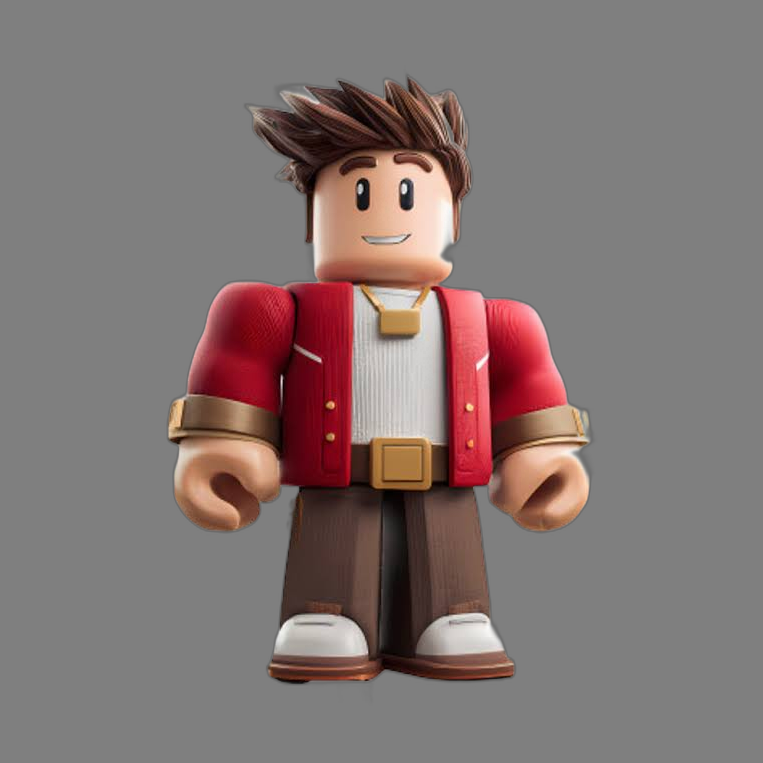


 experiment_2


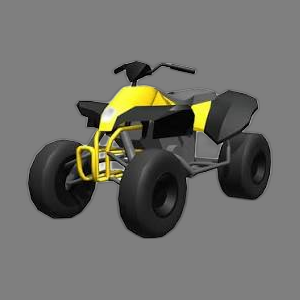


 experiment_3


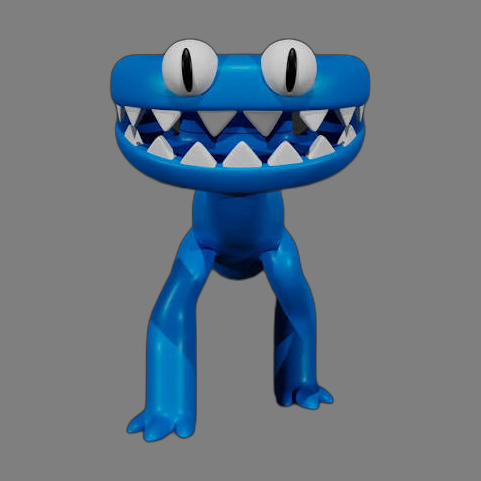

In [18]:
# CELL 10 — Display processed inputs used by TripoSR
# Screenshot at least one of these for your report.

from PIL import Image
from pathlib import Path
from IPython.display import display

out_root = Path("/content/triposr_outputs")

for exp_dir in sorted(out_root.glob("experiment_*")):
    img_path = exp_dir / "processed_input.png"
    print("\n", exp_dir.name)
    img = Image.open(img_path)
    display(img)

In [19]:
# CELL 11 — Load the saved metrics into a clean evidence table.
# Screenshot this cell for the report.

import json
from pathlib import Path

records = json.loads(
    Path("/content/triposr_outputs/triposr_results.json").read_text()
)

print("-" * 120)
print(
    f"{'Exp':<5}{'Input':<28}{'Time(s)':>10}{'VRAM GB':>10}"
    f"{'Vertices':>12}{'Faces':>12}{'Water':>10}{'Comp':>8}"
)
print("-" * 120)

for r in records:
    print(
        f"{r['experiment']:<5}"
        f"{r['input_file'][:26]:<28}"
        f"{r['inference_and_mesh_seconds']:>10.3f}"
        f"{r['peak_allocated_vram_GB']:>10.3f}"
        f"{r['vertices']:>12}"
        f"{r['faces']:>12}"
        f"{str(r['watertight']):>10}"
        f"{r['connected_components']:>8}"
    )

------------------------------------------------------------------------------------------------------------------------
Exp  Input                          Time(s)   VRAM GB    Vertices       Faces     Water    Comp
------------------------------------------------------------------------------------------------------------------------
1    images (3).jpg                   3.542     1.892       27925       55838      True       4
2    images (4).jpg                   1.909     1.892       45050       90088      True      13
3    images (5).jpg                   2.194     1.892       27913       55846      True       2


In [20]:
# CELL 12 — Interactive 3D mesh viewer.
# Rotate each mesh to a useful angle and take screenshots.

import sys, subprocess, json, numpy as np

# Install lightweight viewer packages in the notebook's main Python if needed.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "trimesh==4.0.5", "plotly"],
    check=True
)

import trimesh
import plotly.graph_objects as go
from pathlib import Path

records = json.loads(
    Path("/content/triposr_outputs/triposr_results.json").read_text()
)

for r in records:
    mesh = trimesh.load(r["mesh_path"], force="mesh")
    v = np.asarray(mesh.vertices)
    f = np.asarray(mesh.faces)

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=v[:, 0], y=v[:, 1], z=v[:, 2],
                i=f[:, 0], j=f[:, 1], k=f[:, 2],
                intensity=v[:, 2],
                colorscale="Viridis",
                showscale=False,
                flatshading=False,
            )
        ]
    )

    fig.update_layout(
        title=f"TripoSR output — {r['input_file']}",
        scene_aspectmode="data",
        width=800,
        height=650,
        margin=dict(l=0, r=0, b=0, t=45),
    )

    fig.show()

# What to discuss in Section 3.2

For each object, write down what you actually observe:

**1. Visible-shape fidelity**  
Does the output preserve the silhouette and major visible features?

**2. Hidden-side ambiguity**  
Because TripoSR receives only one RGB image, what geometry does it have to infer for unseen surfaces?

**3. Thin structures**  
Are legs, spokes, handles, mirrors, doors or similar features preserved, fused or lost?

**4. Topology**  
Use the measured `watertight` and `connected_components` values. A model can be watertight but still have several disconnected pieces.

**5. Surface artifacts**  
Look for dents, flattened regions, fused parts, missing gaps and asymmetry.

**6. Efficiency**  
Quote the actual measured inference time and peak allocated GPU memory.

**7. Direct connection to Section 3.1**  
TripoSR is a **single-image-conditioned feed-forward reconstruction system**, whereas Cube 3D uses **text/bounding-box conditioning and autoregressive discrete shape-token generation**. Your experiment should therefore compare both:
- **conditioning:** image vs text/spatial condition;
- **generation mechanism:** feed-forward reconstruction vs autoregressive next-token generation;
- **3D representation:** triplane/NeRF-style representation vs Cube's discrete shape tokens and implicit decoder;
- **practical behaviour:** speed, geometry quality, hidden-side inference, disconnected components and control.

## Suggested figures
- **Figure A:** T4 GPU/runtime evidence.
- **Figure B:** TripoSR input/processed image.
- **Figure C:** strongest generated mesh.
- **Figure D:** mesh showing a limitation.
- **Table:** runtime, VRAM, vertices, faces, watertightness and connected components.

In [21]:
# CELL 13 — Download all experiment evidence as one ZIP.

import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/COMP8410_TripoSR_Evidence",
    "zip",
    "/content/triposr_outputs",
)

print("Created:", zip_path)
files.download(zip_path)

Created: /content/COMP8410_TripoSR_Evidence.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>